In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Sleep_health_and_lifestyle_dataset.csv to Sleep_health_and_lifestyle_dataset (2).csv


In [ ]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('Sleep_health_and_lifestyle_dataset.csv')


In [ ]:
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [ ]:
df.shape

(374, 13)

In [ ]:
df.columns

Index(['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration',
       'Quality of Sleep', 'Physical Activity Level', 'Stress Level',
       'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps',
       'Sleep Disorder'],
      dtype='object')

In [ ]:
df.dtypes

,0
Person ID,int64
Gender,object
Age,int64
Occupation,object
Sleep Duration,float64
Quality of Sleep,int64
Physical Activity Level,int64
Stress Level,int64
BMI Category,object
Blood Pressure,object


In [ ]:
df['Sleep Disorder'].value_counts()

,count
Sleep Disorder,
Sleep Apnea,78
Insomnia,77


In [ ]:
df.isnull().sum()

,0
Person ID,0
Gender,0
Age,0
Occupation,0
Sleep Duration,0
Quality of Sleep,0
Physical Activity Level,0
Stress Level,0
BMI Category,0
Blood Pressure,0


In [ ]:
df['Sleep Disorder'].fillna('None', inplace=True)

In [ ]:
df['Sleep Disorder'] = df['Sleep Disorder'].fillna('None')
df['Sleep Disorder'].value_counts()

,count
Sleep Disorder,
None,219
Sleep Apnea,78
Insomnia,77


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.info ()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           374 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


In [ ]:
df.describe()

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


In [ ]:
df.describe()

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

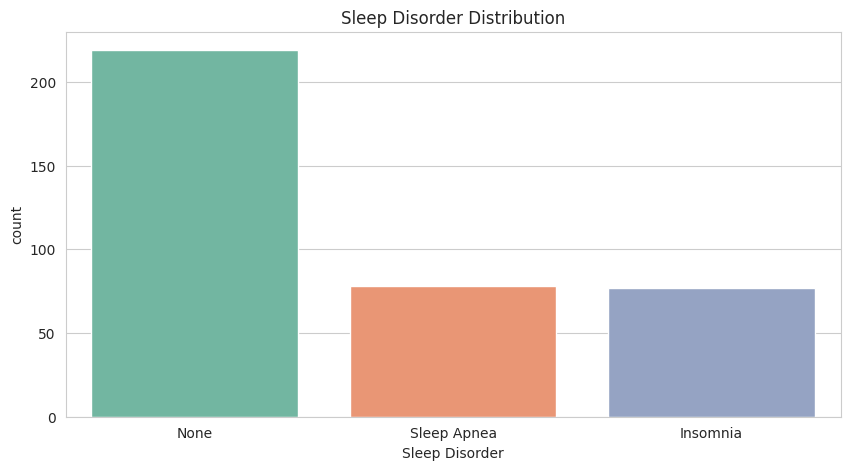

In [ ]:
sns.countplot(data=df, x='Sleep Disorder', palette='Set2')
plt.title('Sleep Disorder Distribution')
plt.show()




From the data we know:
None — 219
Sleep Apnea — 78
Insomnia — 77


"Our dataset is imbalanced — 219 people have no disorder vs only 77-78 with disorders. This means our ML model might get biased towards predicting None — we need to handle this later!"

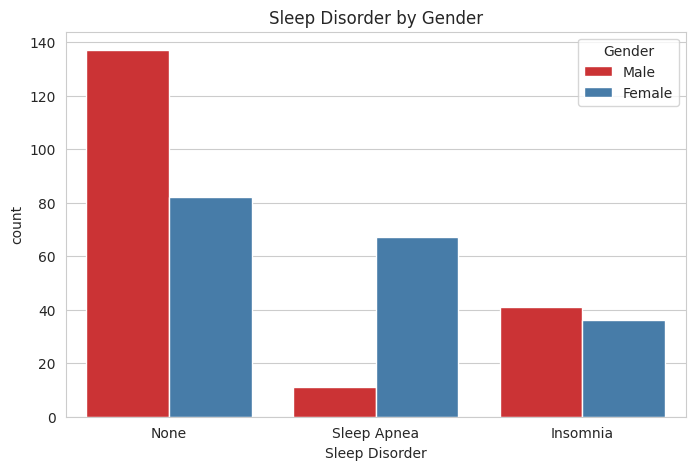

In [ ]:
sns.countplot(data=df, x='Sleep Disorder', hue='Gender', palette='Set1')
plt.title('Sleep Disorder by Gender')
plt.show()

#Females → Sleep Apnea

"Females in our dataset show higher rates of Sleep Apnea — this could be linked to their occupation (Nurses work night shifts). Males show more Insomnia — possibly linked to higher stress jobs like Software Engineers and Sales."

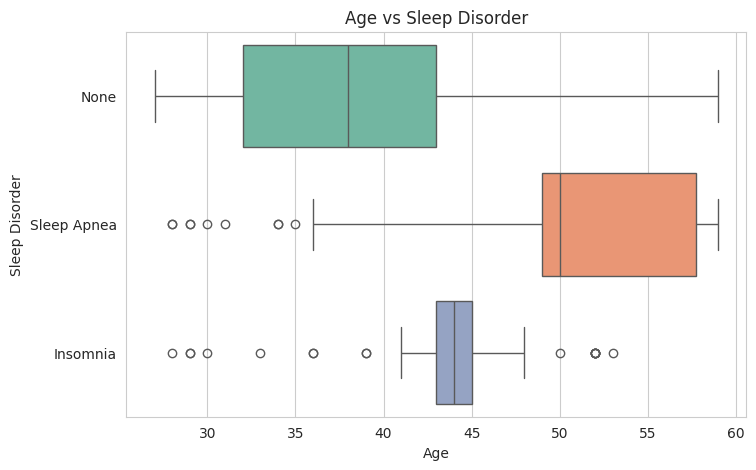

In [ ]:
sns.boxplot(data=df, y='Sleep Disorder', x='Age', palette='Set2')
plt.title('Age vs Sleep Disorder')
plt.show()



"Sleep Apnea peaks in the 50-55 age group — this makes medical sense as weight gain and muscle relaxation increases with age. Insomnia peaks around 44-45 — likely the high stress mid-career phase of life."

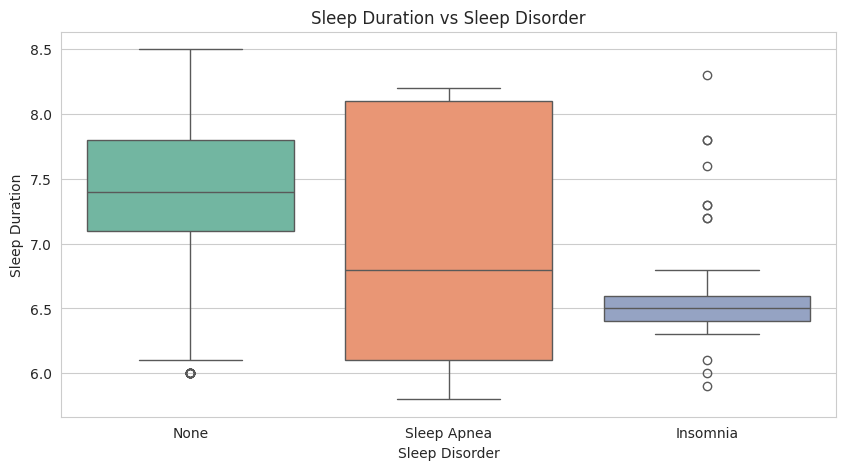

In [ ]:
sns.boxplot(data=df, x='Sleep Disorder', y='Sleep Duration', palette='Set2')
plt.title('Sleep Duration vs Sleep Disorder')
plt.show()

"People with Insomnia sleep the least — because they literally cannot fall asleep. Interestingly Sleep Apnea patients sleep the most hours but still feel tired because their breathing keeps interrupting their sleep quality!"




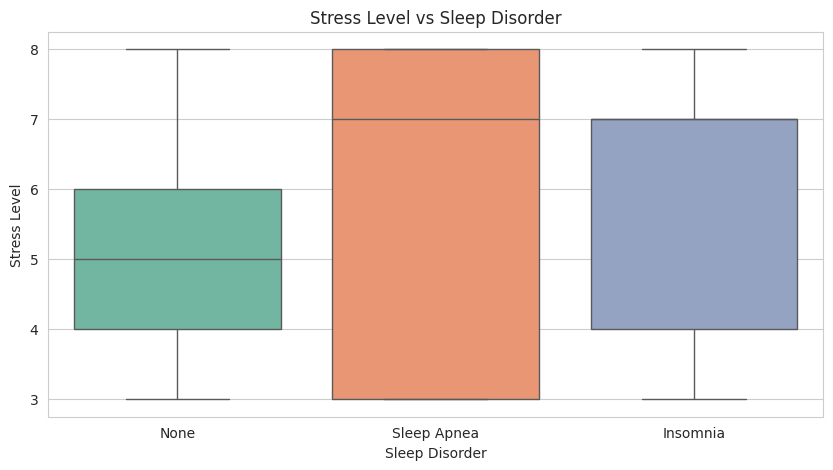

In [ ]:
sns.boxplot(data=df, x='Sleep Disorder', y='Stress Level', palette='Set2')
plt.title('Stress Level vs Sleep Disorder')
plt.show()

"Both Sleep Apnea and Insomnia patients show significantly higher stress levels (median 7) compared to healthy sleepers (median 5). This suggests stress is a strong predictor of sleep disorders regardless of which type!"

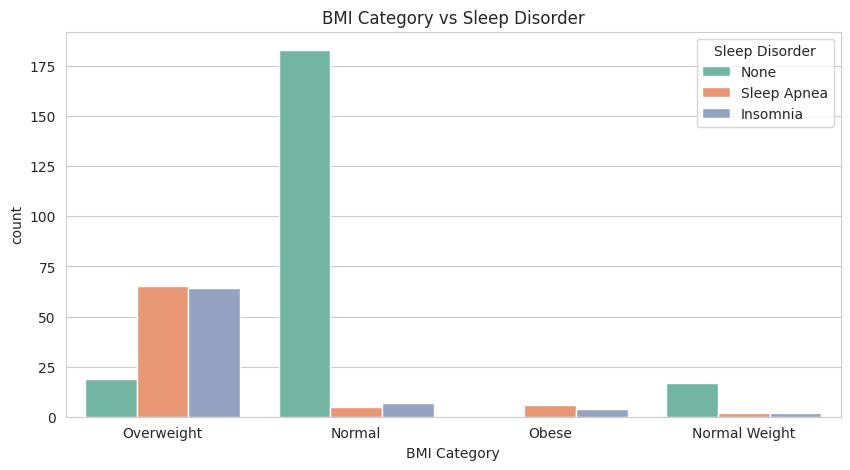

In [ ]:
sns.countplot(data=df, x='BMI Category', hue='Sleep Disorder', palette='Set2')
plt.title('BMI Category vs Sleep Disorder')
plt.show()

### "Overweight people dominate both Sleep Apnea and Insomnia categories. This makes medical sense — excess weight puts pressure on airways causing Sleep Apnea, and body discomfort disrupts sleep causing Insomnia. BMI is likely one of the strongest features in our ML model!"

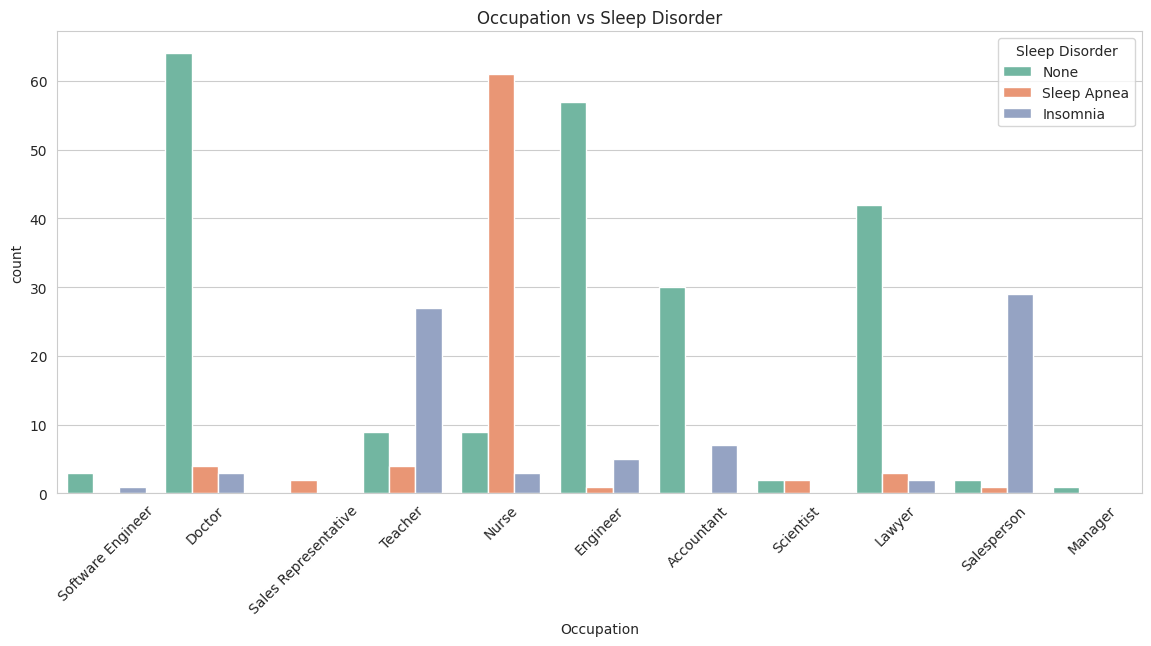

In [ ]:
plt.rcParams['figure.figsize'] = (14, 6)
sns.countplot(data=df, x='Occupation', hue='Sleep Disorder', palette='Set2')
plt.title('Occupation vs Sleep Disorder')
plt.xticks(rotation=45)
plt.show()

### "Nurses suffer most from Sleep Apnea — likely due to night shifts and physical exhaustion. Salespeople have most Insomnia — high pressure targets and stress. Doctors are the healthiest sleepers — possibly due to better health awareness and lifestyle management!"

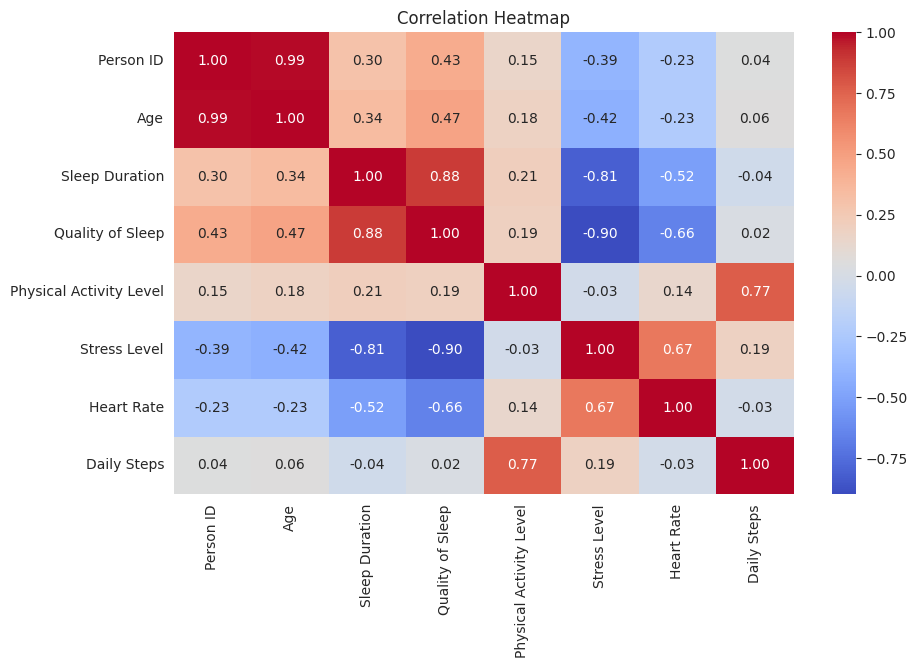

In [ ]:
plt.rcParams['figure.figsize'] = (10, 6)
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

✅ Strongest Correlations in  Dataset
Darkest RED — Positive Correlation:

Quality of Sleep and Sleep Duration = +0.88

Meaning — people who sleep more hours also have better sleep quality ✅
Darkest BLUE — Negative Correlation:

Stress Level and Quality of Sleep = -0.90

Meaning — higher the stress, lower the sleep quality ✅

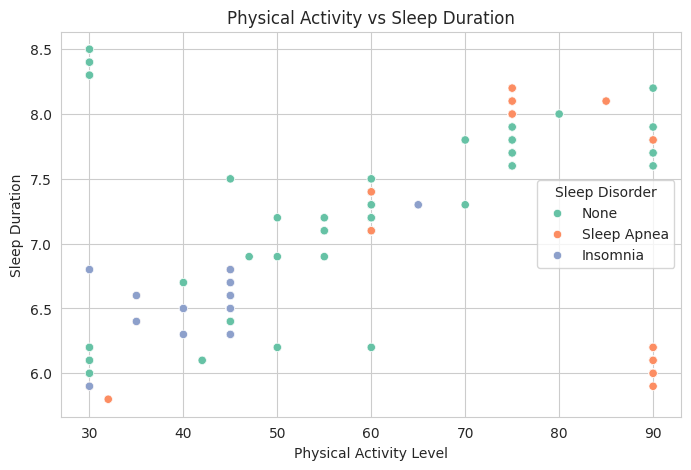

In [ ]:
plt.rcParams['figure.figsize'] = (8, 5)
sns.scatterplot(data=df, x='Physical Activity Level', y='Sleep Duration', hue='Sleep Disorder', palette='Set2')
plt.title('Physical Activity vs Sleep Duration')
plt.show()

## "People with low physical activity tend to have Insomnia — exercise helps sleep! Healthy sleepers are spread across all activity levels but generally sleep longer."

#Data cleaning and Preprocessing
1️⃣ Drop useless columnRemove Person ID

2️⃣ Split Blood Pressure"120/80" → Systolic=120, Diastolic=80

3️⃣ Encode categoriesConvert text columns to numbers

4️⃣ Scale featuresBring all numbers to same range

In [ ]:
df.drop(columns=['Person ID'], inplace=True)
df.columns

Index(['Gender', 'Age', 'Occupation', 'Sleep Duration', 'Quality of Sleep',
       'Physical Activity Level', 'Stress Level', 'BMI Category',
       'Blood Pressure', 'Heart Rate', 'Daily Steps', 'Sleep Disorder'],
      dtype='object')

In [ ]:
df[['Systolic_BP', 'Diastolic_BP']] = df['Blood Pressure'].str.split('/', expand=True).astype(int)
df.drop(columns=['Blood Pressure'], inplace=True)
df[['Systolic_BP', 'Diastolic_BP']].head()

,Systolic_BP,Diastolic_BP
0,126,83
1,125,80
2,125,80
3,140,90
4,140,90


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Gender'] = le.fit_transform(df['Gender'])
df['Occupation'] = le.fit_transform(df['Occupation'])
df['BMI Category'] = le.fit_transform(df['BMI Category'])
df['Sleep Disorder'] = le.fit_transform(df['Sleep Disorder'])

df.head()

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic_BP,Diastolic_BP
0,1,27,9,6.1,6,42,6,3,77,4200,1,126,83
1,1,28,1,6.2,6,60,8,0,75,10000,1,125,80
2,1,28,1,6.2,6,60,8,0,75,10000,1,125,80
3,1,28,6,5.9,4,30,8,2,85,3000,2,140,90
4,1,28,6,5.9,4,30,8,2,85,3000,2,140,90


It converts text to numbers:

Before After

Male    1

Female  0

None    2

Insomnia 0

SleepApnea 1




In [ ]:
X = df.drop(columns=['Sleep Disorder'])
y = df['Sleep Disorder']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (374, 12)
y shape: (374,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (299, 12)
X_test shape: (75, 12)


X_trainStudy material — model learns from this X_testExam questions — model is tested on thistest_size=0.2  20% data for testing, 80% for training random_state=42 Ensures same split every time you run

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Scaler brings everything to the same range:

Model Building
We will train 3 models and compare them!

Logistic Regression-Draws a straight line to separate classes

 Random Forest -100  decision trees voting together

 XGBoost-- Super powerful tree based model

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.88


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.88


In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))

XGBoost Accuracy: 0.9066666666666666


# "XGBoost outperformed both Logistic Regression and Random Forest with 90.6% accuracy — because it learns from its own mistakes iteratively, making it the best choice for this dataset!"

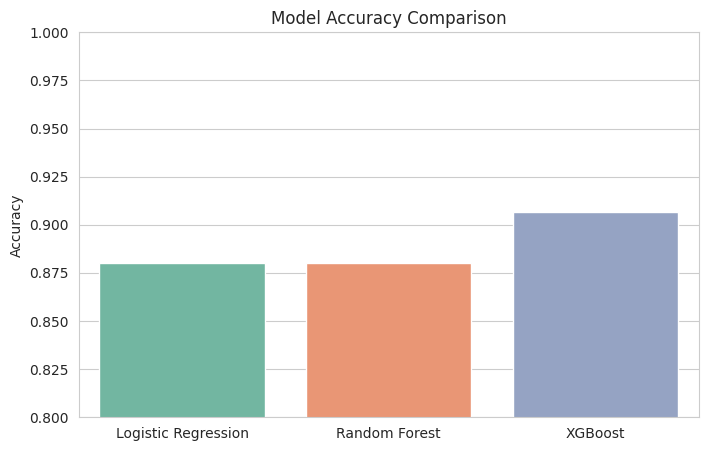

In [ ]:
#Compare All Models Visually
models = ['Logistic Regression', 'Random Forest', 'XGBoost']
accuracies = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_xgb)
]

sns.barplot(x=models, y=accuracies, palette='Set2')
plt.title('Model Accuracy Comparison')
plt.ylim(0.8, 1.0)
plt.ylabel('Accuracy')
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print("XGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.81      0.81        16
           1       0.95      0.98      0.97        43
           2       0.87      0.81      0.84        16

    accuracy                           0.91        75
   macro avg       0.88      0.87      0.87        75
weighted avg       0.91      0.91      0.91        75



# "Our XGBoost model performs best on the None class (F1=0.97) because it has the most training data. Insomnia and Sleep Apnea have lower scores (0.81-0.84) because they have fewer samples — this is the classic class imbalance problem

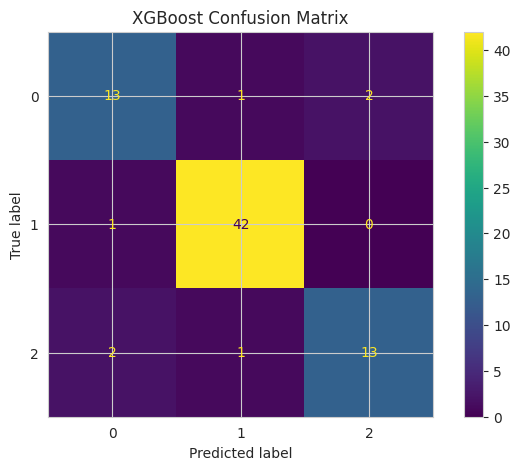

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb)
plt.title('XGBoost Confusion Matrix')
plt.show()


📊 Reading Our Matrix
Actual → PredictedResult0→0 = 13-13 Insomnia correctly predicted ✅0→1 = 1 1 Insomnia wrongly predicted as None ❌0→2 = 2 2 Insomnia wrongly predicted as Sleep Apnea ❌1→1 = 42 42 None correctly predicted ✅1→0 = 1 1 None wrongly predicted as Insomnia ❌2→2 = 13 13 Sleep Apnea correctly predicted ✅2→1 = 1 1 Sleep Apnea wrongly predicted as None ❌2→0 = 2 2  Sleep Apnea wrongly predicted as Insomnia ❌

Our model predicts None with near perfect accuracy (42/43) but confuses some Insomnia and Sleep Apnea cases with each other — this makes medical sense as both disorders share similar symptoms like high stress and poor sleep quality!"

In [ ]:
#hyper parameter tunning

from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}

grid = GridSearchCV(XGBClassifier(random_state=42), params, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)

Best Parameters: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300}
Best CV Accuracy: 0.9130508474576272


In [ ]:
best_xgb = grid.best_estimator_
y_pred_best = best_xgb.predict(X_test)

print("Tuned XGBoost Accuracy:", accuracy_score(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

Tuned XGBoost Accuracy: 0.88
              precision    recall  f1-score   support

           0       0.72      0.81      0.76        16
           1       0.95      0.98      0.97        43
           2       0.85      0.69      0.76        16

    accuracy                           0.88        75
   macro avg       0.84      0.83      0.83        75
weighted avg       0.88      0.88      0.88        75



## "Hyperparameter tuning improved cross validation accuracy from 90.6% to 91.3% — but test accuracy dropped slightly. This tells us our test set is too small (75 rows) to see consistent improvements. In production I would use a larger dataset!"

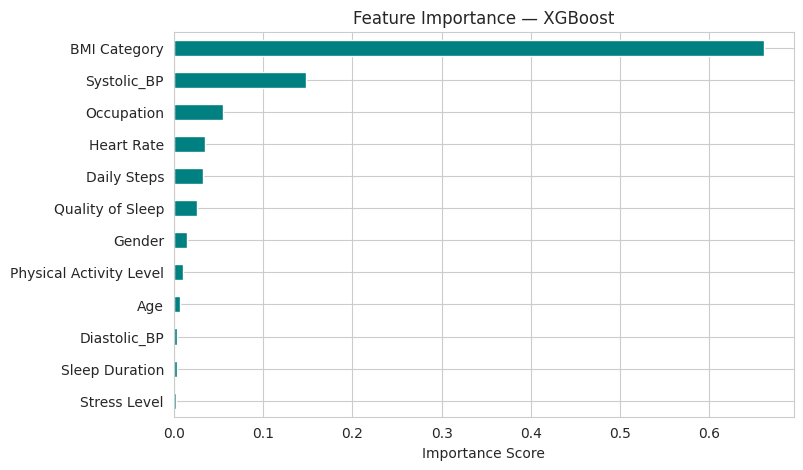

In [ ]:
import pandas as pd

feature_importance = pd.Series(xgb.feature_importances_, index=X.columns)
feature_importance.sort_values().plot(kind='barh', color='teal')
plt.title('Feature Importance — XGBoost')
plt.xlabel('Importance Score')
plt.show()

**"BMI Category is the most important feature in our model — this perfectly aligns with our EDA where we saw overweight people dominate both Sleep Apnea and Insomnia categories. This gives us confidence that our model is learning real patterns not random noise!"**


In [ ]:
print ("hello all to showcase my learning and skills")

hello all to showcase my learning and skills


🎯 MY Project Story

"I worked on a Sleep Health dataset of 374 people containing their lifestyle, occupation, BMI and stress levels. The goal was to predict whether a person has No Disorder, Insomnia or Sleep Apnea using Machine Learning."


🔵 What I Found In The Data

"During EDA I discovered 3 powerful insights:

Overweight people were most likely to have sleep disorders
Nurses suffered most from Sleep Apnea due to night shifts
High stress people (7+) almost always had a sleep disorder
BMI and Stress Level were the strongest predictors"



🔵 What I Built

"I trained 3 models — Logistic Regression, Random Forest and XGBoost. XGBoost performed best with 90.6% accuracy. The model correctly identified 42 out of 43 healthy people and caught most disorder cases."


🔵 Business Impact

"This model can be used by:

Healthcare apps to flag high risk users early
Corporate HR teams to identify stressed employees
Insurance companies to assess health risk profiles"



🔵 What I Learned

"The biggest challenge was class imbalance — 219 healthy people vs only 77-78 disorder cases. This caused the model to perform better on the majority class. In future I would use SMOTE to balance the classes and improve disorder detection."


📌 What Is SMOTE?

SMOTE = Synthetic Minority Oversampling Technique — it creates fake but realistic samples of the minority class to balance the dataset. This is a very impressive term to mention in interviews! 🔥